# Trabalho de Cálculo Numérico Básico

## Ajuste exponencial e interpolação aplicados ao resfriamento de um corpo
---
## Grupo 8 – Resfriamento de um Corpo

## Integrantes
- Gabriel Silva Aires
- Sâmyla Jennyfer Silva
- Ester Lira da Silva

Neste trabalho é analisado o resfriamento de um corpo a partir de um conjunto de dados experimentais. Foram implementados dois métodos numéricos para modelar o comportamento da temperatura ao longo do tempo:

- Interpolação polinomial de Lagrange;
- Ajuste exponencial utilizando o Método dos Mínimos Quadrados (MMQ).

Ao final, os dois métodos são comparados por meio de gráficos e do erro quadrático médio (EQM).

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import csv
from numpy import linspace
from math import exp, log
from math import prod as produtorio
somatorio = sum

## Dados

Os dados utilizados representam a temperatura de um objeto em função do tempo.

In [24]:
def carregar_dados(caminho):
    with open(caminho, mode='r', encoding='utf-8') as arquivo:
        leitor = csv.DictReader(arquivo)
        dados = [(float(linha['tempo_min']), float(linha['temperatura_c'])) for linha in leitor]

        tempos, temperaturas = zip(*dados)

        return list(tempos), list(temperaturas)


## Interpolação de Lagrange

Como visto em sala de aula, a interpolação de Lagrange constrói um único polinômio capaz de passar por todos os pontos conhecidos.

O algoritmo calcula cada polinômio básico de Lagrange e soma suas contribuições para obter o valor interpolado em qualquer ponto do intervalo.

In [25]:
def lagrange(x, y, ponto):
    return somatorio(
        y[i] * produtorio(
            (ponto - x[j]) / (x[i] - x[j])

            # len(x) = n
            for j in range(len(x))
            if i != j
        )
        for i in range(len(x))
    )

def gerar_curva_interpolacao(x, y, quantidade=500):
    """
    Pequeno helper criado para preparar um gráfico.
    """

    eixo_x = linspace(min(x), max(x), quantidade)

    eixo_y = [
        lagrange(x, y, ponto)
        for ponto in eixo_x
    ]

    return eixo_x, eixo_y


## Ajuste exponencial por Mínimos Quadrados

O resfriamento de um corpo pode ser modelado aproximadamente pela Lei de Resfriamento de Newton (uma EDO).

Considerando:

T(t)=Ta+A·e^(-kt), 

é possível linearizar o problema aplicando logaritmo natural:

ln(T−Ta)=ln(A)−kt

Após essa transformação, o problema torna-se um ajuste linear, permitindo utilizar o Método dos Mínimos Quadrados para determinar os coeficientes da reta.

In [26]:
def linearizar(temperaturas, temperatura_ambiente):
    """
    Calcula ln(T - Ta) para cada temperatura.
    """
    return [
        log(temperatura - temperatura_ambiente)
        for temperatura in temperaturas
    ]


def mmq_linear(x, y):
    """
    Ajuste linear por mínimos quadrados.
    """

    n = len(x)
    soma_x = sum(x)
    soma_y = sum(y)
    
    soma_xy = sum(
        xi * yi
        for xi, yi in zip(x, y)
    )

    soma_x2 = sum(
        xi ** 2
        for xi in x
    )

    m = (n * soma_xy - soma_x * soma_y) / (n * soma_x2 - soma_x ** 2)

    b = (soma_y - m * soma_x) / n

    return (m, b)


def modelo_exponencial(tempo, temperatura_ambiente, coeficientes):
    """
    Reconstrói o modelo exponencial.

    ln(T - Ta) = m*t + b
    """
    m, b = coeficientes

    return temperatura_ambiente + exp(m * tempo + b)
    
def erro_quadratico_medio(
    tempos,
    temperaturas,
    temperatura_ambiente,
    coeficientes
):
    return somatorio(
        (
            temperatura_real
            - modelo_exponencial(
                tempo,
                temperatura_ambiente,
                coeficientes
            )
        ) ** 2
        
        for tempo, temperatura_real in zip(
            tempos,
            temperaturas
        )
    ) / len(tempos)


def gerar_curva_mmq(tempos, temperatura_ambiente, coeficientes, quantidade=500):
    """
    Helper para preparar gráfico
    """
    eixo_x = np.linspace(min(tempos), max(tempos), quantidade)

    eixo_y = [
        modelo_exponencial(
            ponto,
            temperatura_ambiente,
            coeficientes
        )
        for ponto in eixo_x
    ]

    return eixo_x, eixo_y


## Aplicação dos métodos

Após implementar os algoritmos, ambos são aplicados ao conjunto de dados de resfriamento.

Nesta etapa são calculados:

- o polinômio interpolador de Lagrange;
- o ajuste exponencial por MMQ;
- o Erro Quadrático Médio (EQM) do modelo exponencial.

In [27]:
TEMPERATURA_AMBIENTE = 25

tempos, temperaturas = carregar_dados(
    "C:/Users/gabri/repos/corpo-resfriamento-calc-numerico/dados/dados_resfriamento.csv"
)

### Interpolação

Inicialmente é construída a curva interpoladora utilizando o método de Lagrange implementado anteriormente.

In [28]:
x_interp, y_interp = gerar_curva_interpolacao(
    tempos,
    temperaturas
)

### Ajuste exponencial

Em seguida, os dados são linearizados e aplica-se o Método dos Mínimos Quadrados para obter os coeficientes do modelo exponencial.

In [29]:
temperaturas_linearizadas = linearizar(
    temperaturas,
    TEMPERATURA_AMBIENTE
)

coeficientes = mmq_linear(
    tempos,
    temperaturas_linearizadas
)

x_mmq, y_mmq = gerar_curva_mmq(
    tempos,
    TEMPERATURA_AMBIENTE,
    coeficientes
)

### Erro Quadrático Médio

O Erro Quadrático Médio (EQM) é utilizado para medir o quanto a curva ajustada se aproxima dos dados observados.

In [30]:
eqm = erro_quadratico_medio(
    tempos,
    temperaturas,
    TEMPERATURA_AMBIENTE,
    coeficientes
)

eqm

0.044853160384531715

## Resultados

Os coeficientes encontrados para o modelo exponencial são apresentados abaixo.

### Coeficientes encontrados

Após aplicar o Método dos Mínimos Quadrados sobre os dados linearizados, foram obtidos os seguintes coeficientes para a reta:

ln(T-Ta)=mt + b

In [31]:
m, b = coeficientes

print(f"Coeficiente angular (m): {m:.6f}")
print(f"Coeficiente linear (b):  {b:.6f}")

Coeficiente angular (m): -0.013467
Coeficiente linear (b):  2.795984


A partir do coeficiente linear é possível reconstruir o parâmetro *A* do modelo exponencial:

*A*=e^b

In [32]:
A = exp(b)

print(f"A = {A:.3f}")

A = 16.379


Substituindo os coeficientes encontrados na equação do modelo, temos:

In [33]:
print(
    f"T(t) = {TEMPERATURA_AMBIENTE:.2f} + "
    f"{A:.3f} · e^({m:.6f} t)"
)

T(t) = 25.00 + 16.379 · e^(-0.013467 t)


O Erro Quadrático Médio (EQM) representa a média dos quadrados dos erros entre os valores observados e os valores estimados pelo modelo.

In [34]:
print(f"EQM = {eqm:.6f}")

EQM = 0.044853


## Comparação gráfica

Dados experimentais

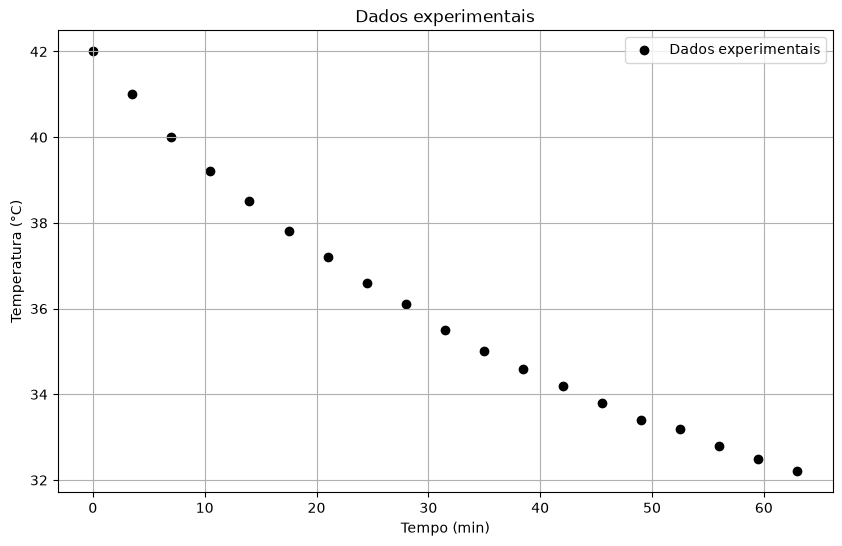

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    tempos,
    temperaturas,
    color="black",
    label="Dados experimentais"
)

plt.xlabel("Tempo (min)")
plt.ylabel("Temperatura (°C)")
plt.title("Dados experimentais")

plt.grid(True)
plt.legend()

plt.show()

Curva obtida pela interpolação de Lagrange.

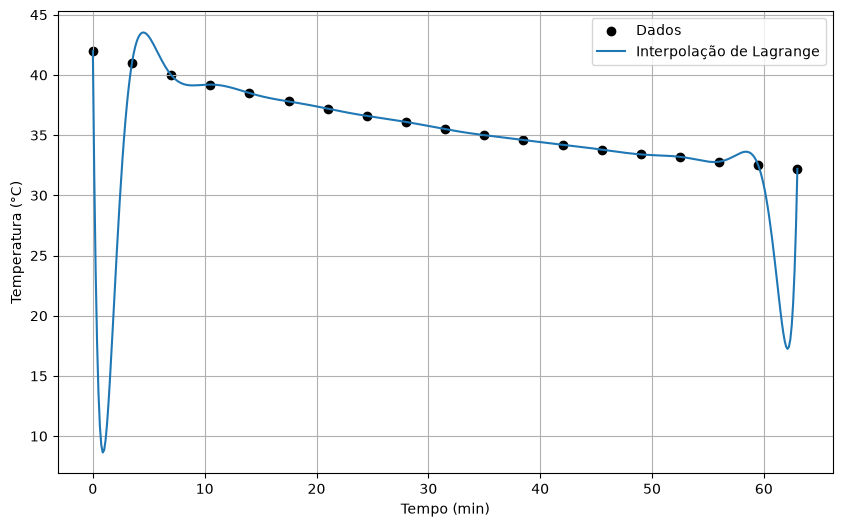

In [36]:
plt.figure(figsize=(10,6))

plt.scatter(
    tempos,
    temperaturas,
    color="black",
    label="Dados"
)

plt.plot(
    x_interp,
    y_interp,
    label="Interpolação de Lagrange"
)

plt.xlabel("Tempo (min)")
plt.ylabel("Temperatura (°C)")

plt.grid(True)
plt.legend()

plt.show()

A figura seguinte apresenta apenas o ajuste exponencial obtido pelo MMQ.

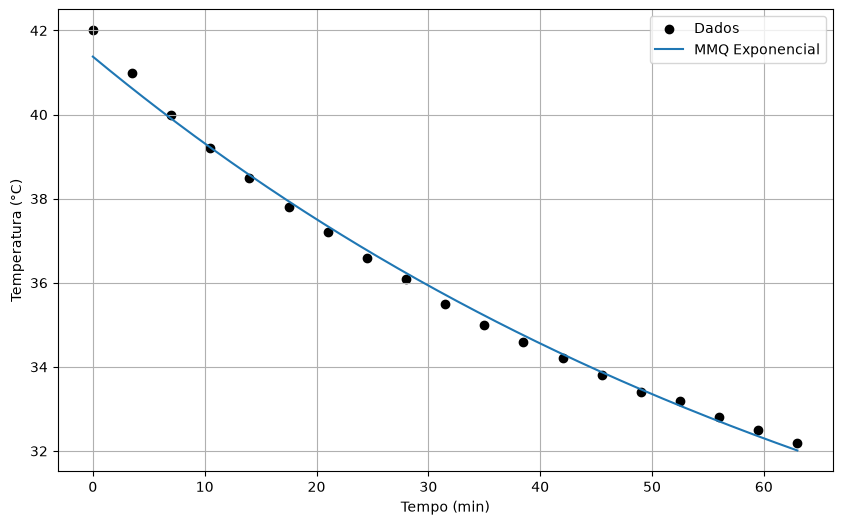

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(
    tempos,
    temperaturas,
    color="black",
    label="Dados"
)

plt.plot(
    x_mmq,
    y_mmq,
    label="MMQ Exponencial"
)

plt.xlabel("Tempo (min)")
plt.ylabel("Temperatura (°C)")

plt.grid(True)
plt.legend()

plt.show()

Por fim, os dois métodos apresentados simultaneamente para comparação:

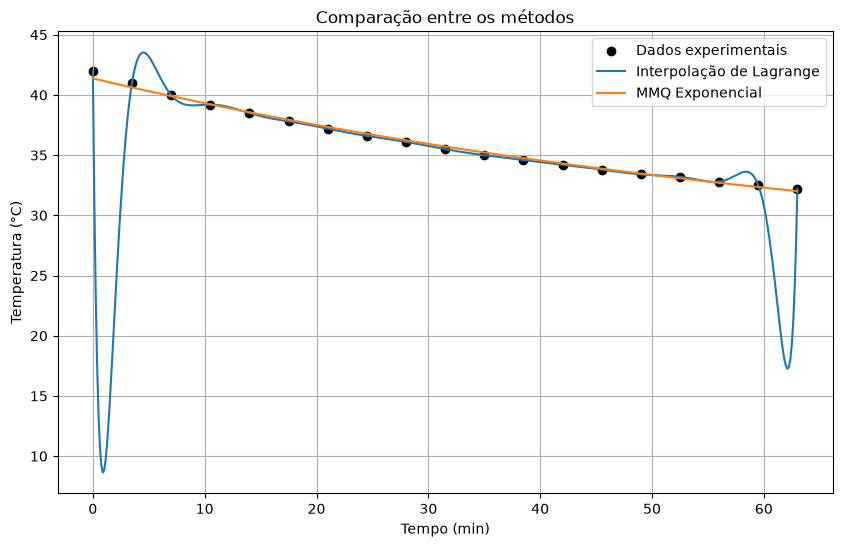

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    tempos,
    temperaturas,
    color="black",
    label="Dados experimentais"
)

plt.plot(
    x_interp,
    y_interp,
    label="Interpolação de Lagrange"
)

plt.plot(
    x_mmq,
    y_mmq,
    label="MMQ Exponencial"
)

plt.xlabel("Tempo (min)")
plt.ylabel("Temperatura (°C)")
plt.title("Comparação entre os métodos")

plt.grid(True)
plt.legend()

plt.show()